# Document Scanner Notebook:

This notebook demonstrates a step-by-step geometric pipeline designed to transform a raw input image from the ``MIDV-500 dataset`` into a perfectly clean, "scanned" document. The workflow is structured as follows:

**Raw Image → Document Detection → Perspective Correction → Final "Scanned" Image**

Rather than just displaying the final output, each intermediate step is visualized independently. This modular approach allows you to see exactly what each algorithm does to the image structure and how the data is manipulated at every stage of the pipeline.

In [2]:
import cv2 # for openCV
import numpy as np
import matplotlib.pyplot as plt # for displaying images
import glob, os, json # for reading jsons, files

import scanner  # out module (scanner.py)

# helper function to display the image in the right format
def show(img, title='', cmap=None, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 7))
    if len(img.shape) == 3:
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        ax.imshow(img, cmap=cmap or 'gray')
    ax.set_title(title)
    ax.axis('off')

## Phase 1: Input

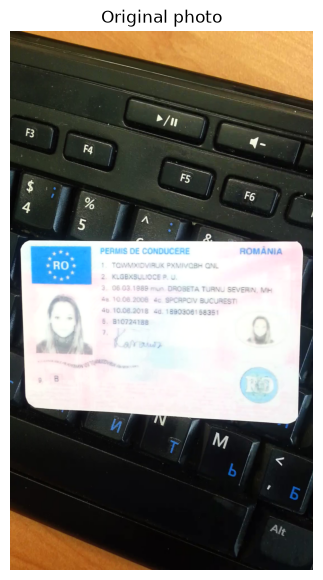

In [ ]:
IMG_PATH = 'data/38_rou_drvlic/images/KS/KS38_02.tif'  # change the path according to your preference
image = cv2.imread(IMG_PATH)
show(image, 'Original photo')

## Phase 2: Computer Vision Pre-Processing (Finding the Edges)

To isolate the document's boundaries, the raw image passes through a clean pre-processing pipeline designed to filter out background noise and extract sharp geometric structures:

* **Grayscale Conversion**: Discards color variations to focus the algorithm strictly on changes in light intensity and contrast.

* **Gaussian Blur**: Smooths the image to eliminate high-frequency noise and textures that could cause false edge detections.

* **Canny Edge Detection**: Computes intensity gradients to locate sharp structural boundaries, producing a clean binary mask of all edges.

* **Contour Isolation**: Parses the edge mask to find continuous shapes, filtering for the largest four-sided polygon that defines the document.

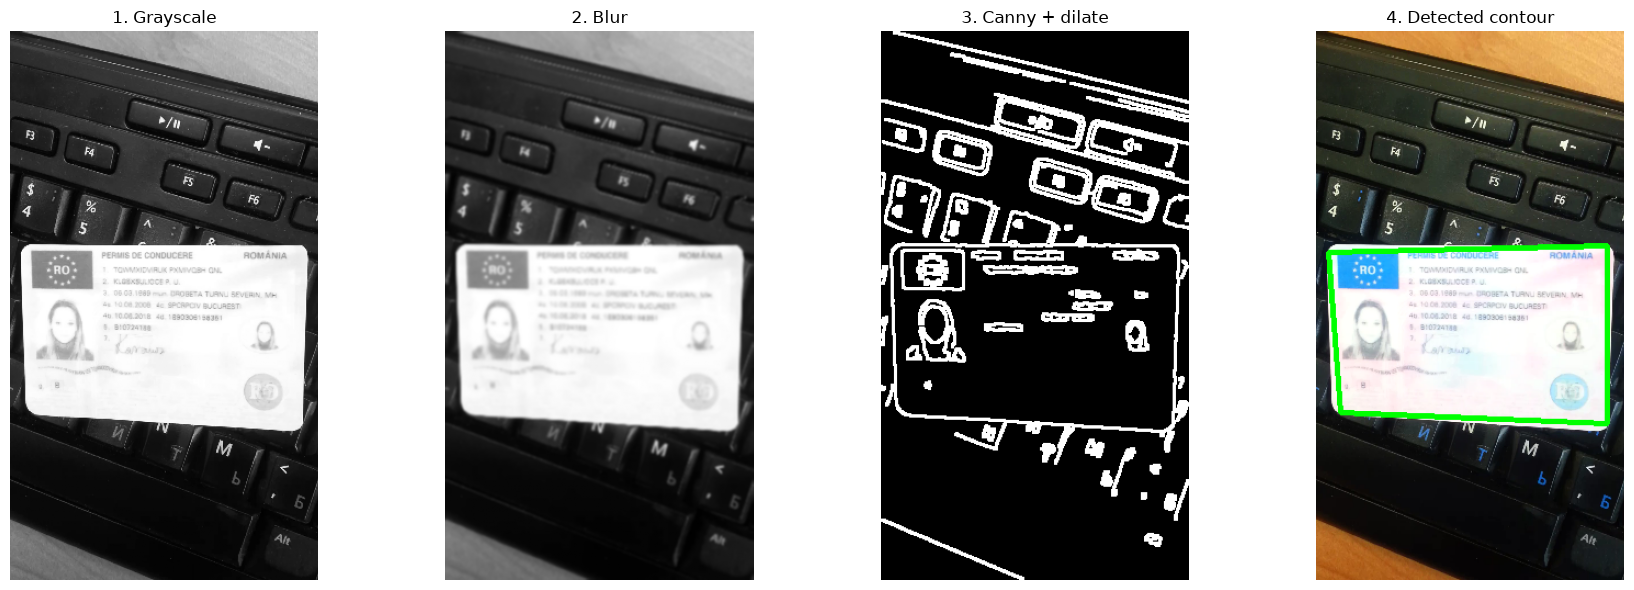

In [4]:
resize_height = 500
ratio = image.shape[0] / float(resize_height)
small = cv2.resize(image, (int(image.shape[1] / ratio), resize_height))

# for first step (grayscale)
gray = cv2.cvtColor(small, cv2.COLOR_BGR2GRAY)

# for second step (blur)
blur = cv2.GaussianBlur(gray, (5, 5), 0)

# for third step (canny + dilate)
edged = cv2.Canny(blur, 50, 150)
edged = cv2.dilate(edged, np.ones((3,3), np.uint8), iterations=1)

fig, axes = plt.subplots(1, 4, figsize=(18, 6))
show(gray, '1. Grayscale', ax=axes[0])
show(blur, '2. Blur', ax=axes[1])
show(edged, '3. Canny + dilate', ax=axes[2])

quad = scanner.detect_document(image)
vis = small.copy()
if quad is not None:
    cv2.polylines(vis, [np.int32(scanner.order_points(quad/ratio))], True, (0,255,0), 3)

# for the fourth step
show(vis, '4. Detected contour', ax=axes[3])
plt.tight_layout()

## Phase 3: Perspective Correction + Enhancement

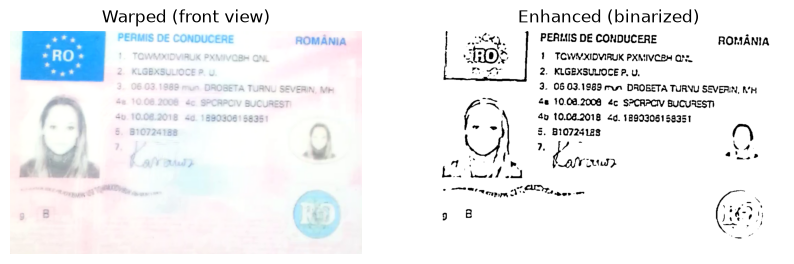

In [5]:
if quad is not None:
    # takes the photo and the four corners and transforms the document in one rectangle
    warped = scanner.four_point_transform(image, quad)
    final = scanner.enhance(warped)
    fig, axes = plt.subplots(1, 2, figsize=(10, 7))
    show(warped, 'Warped (front view)', ax=axes[0])
    show(final, 'Enhanced (binarized)', ax=axes[1])
else:
    print('No document found, fallback.')

## Phase 4: Batch Processing & Visual Logging

The final cell runs the complete scanner pipeline (`scanner.scan()`) over all images in the dataset. For each image where a document is successfully detected, it saves a side-by-side before/after comparison to the `examples/` folder. It also prints a summary table showing which images were detected and the overall detection rate.

In [7]:
os.makedirs('examples', exist_ok=True)
results = []
for f in sorted(glob.glob('data/38_rou_drvlic/images/KS/*.tif')): # change the path according to your preference
    img = cv2.imread(f)
    out, q, ok = scanner.scan(img)
    name = os.path.basename(f).replace('.tif', '')
    results.append((name, ok))
    # saves before/after
    if ok:
        fig, ax = plt.subplots(1, 2, figsize=(8, 6))
        show(img, 'before', ax=ax[0]); show(out, 'after', ax=ax[1])
        plt.savefig(f'examples/{name}.png', bbox_inches='tight', dpi=80)
        plt.close()

print(f'{"name":12} {"found":6}')
for name, ok in results:
    print(f'{name:12} {str(ok):6}')

found = sum(1 for r in results if r[1])
print(f'\nDetection rate: {found}/{len(results)}')

name         found 
KS38_01      True  
KS38_02      True  
KS38_03      True  
KS38_04      True  
KS38_05      True  
KS38_06      True  
KS38_07      True  
KS38_08      True  
KS38_09      False 
KS38_10      True  
KS38_11      True  
KS38_12      True  
KS38_13      True  
KS38_14      True  
KS38_15      True  
KS38_16      True  
KS38_17      True  
KS38_18      True  
KS38_19      True  
KS38_20      True  
KS38_21      True  
KS38_22      True  
KS38_23      True  
KS38_24      True  
KS38_25      True  
KS38_26      True  
KS38_27      True  
KS38_28      True  
KS38_29      True  
KS38_30      True  

Detection rate: 29/30
